# Attention-Augmented LSTM — Advanced (AG News + 20 Newsgroups Fine-Tuned)

This notebook trains a production-ready classifier by combining **AG News** and **20 Newsgroups** into a unified **5-class** taxonomy purpose-built for HN / Reddit-style content.

**Why five classes:** AG News “Sci/Tech” mixes technology and science (NASA, medicine, space, etc.). Splitting that stream from a small 20NG `sci.med` / `sci.space` slice trained the model to label almost all sci/tech as “Technology.” Merging **Technology + Science** into **Tech & Science** aligns labels with what the data actually supports.

## Unified Category Map

| # | Label | Sources |
|---|---|---|
| 0 | Tech & Science | AG News Sci/Tech + comp.* + sci.electronics + sci.med + sci.space |
| 1 | Business | AG News Business (20NG `misc.forsale` excluded — Usenet classifieds, not business news) |
| 2 | World News | AG News World + talk.politics.* |
| 3 | Sports | AG News Sports + rec.sport.* |
| 4 | Security | sci.crypt (1990s crypto discussion; manual tests use PGP/RSA/SSL-style wording) |

## Pipeline
```
AG News (HuggingFace)  +  20 Newsgroups (sklearn)
              ↓
      Category remapping & merge
              ↓
      Shared vocabulary build
              ↓
   Bidirectional LSTM + Attention
              ↓
     Train → Evaluate → Save
              ↓
   Reload saved model → Test
```

## 1. Imports & Setup

In [1]:
import sys
import subprocess


def pip_install(*args):
    subprocess.check_call([sys.executable, "-m", "pip", "install", *args])


# Core libs used by the notebook
pip_install("--upgrade", "pip")
pip_install("datasets", "scikit-learn", "matplotlib", "seaborn")

# PyTorch install with fallback (CUDA 12.1 -> CPU)
try:
    pip_install("torch", "torchvision", "torchaudio", "--index-url", "https://download.pytorch.org/whl/cu121")
except subprocess.CalledProcessError:
    print("cu121 wheels not available for this Python/platform. Falling back to CPU wheels...")
    pip_install("torch", "torchvision", "torchaudio", "--index-url", "https://download.pytorch.org/whl/cpu")

In [2]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, Dataset

import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from datasets import load_dataset
from sklearn.datasets import fetch_20newsgroups
from sklearn.metrics import classification_report, confusion_matrix
from collections import Counter

import re
import pickle
import json
import time
import random
import os

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.backends.cudnn.deterministic = True

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Device : {device}')
if device.type == 'cuda':
    print(f'GPU    : {torch.cuda.get_device_name(0)}')

SAVE_DIR = 'saved_model'
os.makedirs(SAVE_DIR, exist_ok=True)

C:\Users\udaysinh\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\LocalCache\local-packages\Python312\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Device : cuda
GPU    : NVIDIA GeForce RTX 4060 Laptop GPU


## 2. Define Unified Taxonomy

In [3]:
# ── Unified label set (5 classes — Technology + Science merged; see notebook intro) ──
LABEL_NAMES = ['Tech & Science', 'Business', 'World News', 'Sports', 'Security']
N_CLASSES   = len(LABEL_NAMES)
print('Unified classes:', LABEL_NAMES)

# ── AG News mapping  (original: 0=World, 1=Sports, 2=Business, 3=Sci/Tech) ───
AG_MAP = {
    0: 2,   # World     → World News
    1: 3,   # Sports    → Sports
    2: 1,   # Business  → Business
    3: 0,   # Sci/Tech  → Tech & Science
}

# ── 20 Newsgroups mapping  (None = discard noisy/off-topic groups) ────────────
NG_MAP = {
    'comp.graphics'            : 0,   # Tech & Science
    'comp.os.ms-windows.misc'  : 0,
    'comp.sys.ibm.pc.hardware' : 0,
    'comp.sys.mac.hardware'    : 0,
    'comp.windows.x'           : 0,
    'sci.electronics'          : 0,
    'sci.med'                  : 0,   # Tech & Science (aligned with AG Sci/Tech mix)
    'sci.space'                : 0,
    'misc.forsale'             : None,  # classified ads — not business news
    'talk.politics.guns'       : 2,   # World News
    'talk.politics.mideast'    : 2,
    'talk.politics.misc'       : 2,
    'rec.sport.baseball'       : 3,   # Sports
    'rec.sport.hockey'         : 3,
    'sci.crypt'                : 4,   # Security
    # Discarded (off-topic for HN/Reddit)
    'alt.atheism'              : None,
    'rec.autos'                : None,
    'rec.motorcycles'          : None,
    'soc.religion.christian'   : None,
    'talk.religion.misc'       : None,
}

Unified classes: ['Tech & Science', 'Business', 'World News', 'Sports', 'Security']


## 3. Load & Merge Both Datasets

In [4]:
# ── AG News ───────────────────────────────────────────────────────────────────
print('Loading AG News...')
ag = load_dataset('ag_news')

ag_train = [(s['text'], AG_MAP[s['label']]) for s in ag['train']]
ag_test  = [(s['text'], AG_MAP[s['label']]) for s in ag['test']]
print(f'  AG News train: {len(ag_train):,}  |  test: {len(ag_test):,}')

# ── 20 Newsgroups ─────────────────────────────────────────────────────────────
print('Loading 20 Newsgroups...')
ng_train_raw = fetch_20newsgroups(subset='train', remove=('headers', 'footers', 'quotes'))
ng_test_raw  = fetch_20newsgroups(subset='test',  remove=('headers', 'footers', 'quotes'))

def process_ng(raw):
    samples = []
    for text, target in zip(raw.data, raw.target):
        group_name = raw.target_names[target]
        mapped = NG_MAP.get(group_name)
        if mapped is not None and text.strip():
            samples.append((text.strip(), mapped))
    return samples

ng_train = process_ng(ng_train_raw)
ng_test  = process_ng(ng_test_raw)
print(f'  20NG train: {len(ng_train):,}  |  test: {len(ng_test):,}')

# ── Combine ───────────────────────────────────────────────────────────────────
train_all = ag_train + ng_train
test_all  = ag_test  + ng_test

random.shuffle(train_all)
random.shuffle(test_all)

print(f'\nCombined train : {len(train_all):,}')
print(f'Combined test  : {len(test_all):,}')

Loading AG News...


Generating test split: 100%|██████████| 7600/7600 [00:00<00:00, 501632.05 examples/s]


  AG News train: 120,000  |  test: 7,600
Loading 20 Newsgroups...
  20NG train: 7,872  |  test: 5,234

Combined train : 127,872
Combined test  : 12,834


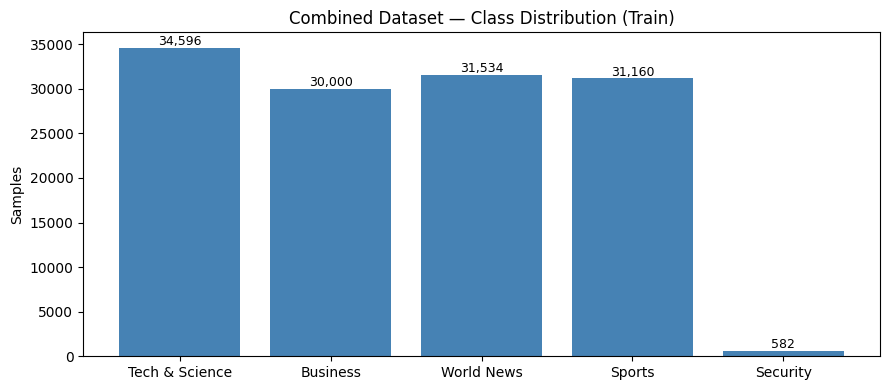

In [5]:
# Class distribution in combined training set
label_counts = Counter(label for _, label in train_all)

plt.figure(figsize=(9, 4))
bars = plt.bar(
    [LABEL_NAMES[k] for k in sorted(label_counts)],
    [label_counts[k] for k in sorted(label_counts)],
    color='steelblue'
)
for bar, k in zip(bars, sorted(label_counts)):
    plt.text(bar.get_x() + bar.get_width() / 2,
             bar.get_height() + 300,
             f'{label_counts[k]:,}', ha='center', fontsize=9)
plt.title('Combined Dataset — Class Distribution (Train)')
plt.ylabel('Samples')
plt.tight_layout()
plt.savefig(f'{SAVE_DIR}/class_distribution.png', dpi=150)
plt.show()

## 4. Preprocessing & Vocabulary

In [6]:
# ── Hyperparameters ────────────────────────────────────────────────────────────
MAX_VOCAB   = 40_000
MAX_SEQ_LEN = 256
EMBED_DIM   = 128
HIDDEN_DIM  = 256
N_LAYERS    = 2
DROPOUT     = 0.4
BATCH_SIZE  = 128
N_EPOCHS    = 10
LR          = 1e-3
# ───────────────────────────────────────────────────────────────────────────────

PAD_TOKEN = '<PAD>'
UNK_TOKEN = '<UNK>'

def tokenize(text: str):
    return re.findall(r'\b[a-z0-9]+\b', text.lower())

# Build vocab from training data only
print('Building vocabulary...')
counter = Counter()
for text, _ in train_all:
    counter.update(tokenize(text))

vocab_words = [w for w, _ in counter.most_common(MAX_VOCAB)]
word2idx = {PAD_TOKEN: 0, UNK_TOKEN: 1}
word2idx.update({w: i + 2 for i, w in enumerate(vocab_words)})
idx2word = {v: k for k, v in word2idx.items()}
VOCAB_SIZE = len(word2idx)
print(f'Vocabulary size: {VOCAB_SIZE:,}')

def encode(text: str, max_len: int = MAX_SEQ_LEN):
    ids = [word2idx.get(t, 1) for t in tokenize(text)[:max_len]]
    if len(ids) == 0:
        ids = [1]  # UNK — all-PAD rows break attention softmax (NaN loss)
    ids += [0] * (max_len - len(ids))
    return ids

Building vocabulary...
Vocabulary size: 40,002


## 5. Dataset & DataLoaders

In [7]:
class TextDataset(Dataset):
    def __init__(self, samples):
        print(f'  Encoding {len(samples):,} samples...')
        self.x = [torch.tensor(encode(text), dtype=torch.long)  for text, _ in samples]
        self.y = [torch.tensor(label,        dtype=torch.long)  for _, label in samples]

    def __len__(self):          return len(self.y)
    def __getitem__(self, idx): return self.x[idx], self.y[idx]


print('Train dataset:')
train_dataset = TextDataset(train_all)
print('Test dataset:')
test_dataset  = TextDataset(test_all)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True,  num_workers=0, pin_memory=True)
test_loader  = DataLoader(test_dataset,  batch_size=BATCH_SIZE, shuffle=False, num_workers=0, pin_memory=True)

print(f'\nTrain batches : {len(train_loader)}')
print(f'Test batches  : {len(test_loader)}')

Train dataset:
  Encoding 127,872 samples...
Test dataset:
  Encoding 12,834 samples...

Train batches : 999
Test batches  : 101


## 6. Model — Bidirectional LSTM + Bahdanau Attention

In [8]:
class BahdanauAttention(nn.Module):
    """
    Additive self-attention over all LSTM time steps.
      hidden  : (B, T, H)
      returns : context (B, H), weights (B, T)
    """
    def __init__(self, hidden_dim):
        super().__init__()
        self.attn = nn.Linear(hidden_dim, hidden_dim)
        self.v    = nn.Linear(hidden_dim, 1, bias=False)

    def forward(self, hidden, mask=None):
        scores = self.v(torch.tanh(self.attn(hidden))).squeeze(-1)  # (B, T)
        if mask is not None:
            scores = scores.masked_fill(~mask, -1e9)  # not -inf: all-masked rows stay finite
        weights = torch.softmax(scores, dim=-1)                     # (B, T)
        context = torch.bmm(weights.unsqueeze(1), hidden).squeeze(1)# (B, H)
        return context, weights


class AttentionLSTM(nn.Module):
    def __init__(self, vocab_size, embed_dim, hidden_dim,
                 n_layers, n_classes, dropout, pad_idx=0):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, embed_dim, padding_idx=pad_idx)
        self.lstm = nn.LSTM(
            embed_dim, hidden_dim,
            num_layers=n_layers,
            batch_first=True,
            bidirectional=True,
            dropout=dropout if n_layers > 1 else 0.0
        )
        self.attention = BahdanauAttention(hidden_dim * 2)
        self.dropout   = nn.Dropout(dropout)
        self.fc        = nn.Linear(hidden_dim * 2, n_classes)

    def forward(self, x):
        mask     = (x != 0)                                  # (B, T)
        embed    = self.dropout(self.embedding(x))           # (B, T, E)
        out, _   = self.lstm(embed)                          # (B, T, H*2)
        context, weights = self.attention(out, mask)         # (B, H*2)
        logits   = self.fc(self.dropout(context))            # (B, C)
        return logits, weights


model = AttentionLSTM(
    vocab_size=VOCAB_SIZE,
    embed_dim=EMBED_DIM,
    hidden_dim=HIDDEN_DIM,
    n_layers=N_LAYERS,
    n_classes=N_CLASSES,
    dropout=DROPOUT
).to(device)

n_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(model)
print(f'\nTrainable parameters: {n_params:,}')

AttentionLSTM(
  (embedding): Embedding(40002, 128, padding_idx=0)
  (lstm): LSTM(128, 256, num_layers=2, batch_first=True, dropout=0.4, bidirectional=True)
  (attention): BahdanauAttention(
    (attn): Linear(in_features=512, out_features=512, bias=True)
    (v): Linear(in_features=512, out_features=1, bias=False)
  )
  (dropout): Dropout(p=0.4, inplace=False)
  (fc): Linear(in_features=512, out_features=5, bias=True)
)

Trainable parameters: 7,753,477


## 7. Training

In [9]:
# Class weights to handle imbalance (Security has far fewer samples)
label_list  = [label for _, label in train_all]
class_counts = torch.tensor([label_list.count(i) for i in range(N_CLASSES)], dtype=torch.float)
class_weights = (1.0 / class_counts.clamp_min(1.0))
class_weights = (class_weights / class_weights.sum() * N_CLASSES).to(device)
print('Class weights:', {LABEL_NAMES[i]: f'{class_weights[i].item():.3f}' for i in range(N_CLASSES)})

criterion = nn.CrossEntropyLoss(weight=class_weights)
optimizer = optim.Adam(model.parameters(), lr=LR)
scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='max', patience=2, factor=0.5)

Class weights: {'Tech & Science': '0.078', 'Business': '0.090', 'World News': '0.086', 'Sports': '0.087', 'Security': '4.658'}


In [10]:
def train_epoch(model, loader, optimizer, criterion):
    model.train()
    total_loss, correct, total = 0.0, 0, 0
    for x, y in loader:
        x, y = x.to(device), y.to(device)
        optimizer.zero_grad()
        logits, _ = model(x)
        loss = criterion(logits, y)
        loss.backward()
        nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        optimizer.step()
        total_loss += loss.item() * y.size(0)
        correct    += (logits.argmax(1) == y).sum().item()
        total      += y.size(0)
    return total_loss / total, correct / total


@torch.no_grad()
def evaluate(model, loader, criterion):
    model.eval()
    total_loss, correct, total = 0.0, 0, 0
    all_preds, all_labels = [], []
    for x, y in loader:
        x, y = x.to(device), y.to(device)
        logits, _ = model(x)
        loss = criterion(logits, y)
        total_loss += loss.item() * y.size(0)
        preds       = logits.argmax(1)
        correct    += (preds == y).sum().item()
        total      += y.size(0)
        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(y.cpu().numpy())
    return total_loss / total, correct / total, all_preds, all_labels


history = {'train_loss': [], 'train_acc': [], 'val_loss': [], 'val_acc': []}
best_val_acc = 0.0

print(f"{'Epoch':>5}  {'Train Loss':>10}  {'Train Acc':>9}  {'Val Loss':>8}  {'Val Acc':>7}  {'LR':>8}  {'Time':>6}")
print('-' * 72)

for epoch in range(1, N_EPOCHS + 1):
    t0 = time.time()
    tr_loss, tr_acc          = train_epoch(model, train_loader, optimizer, criterion)
    vl_loss, vl_acc, _, _    = evaluate(model, test_loader, criterion)
    elapsed = time.time() - t0

    scheduler.step(vl_acc)
    current_lr = optimizer.param_groups[0]['lr']

    history['train_loss'].append(tr_loss)
    history['train_acc'].append(tr_acc)
    history['val_loss'].append(vl_loss)
    history['val_acc'].append(vl_acc)

    marker = ' <- best' if vl_acc > best_val_acc else ''
    if vl_acc > best_val_acc:
        best_val_acc = vl_acc
        torch.save(model.state_dict(), f'{SAVE_DIR}/best_weights.pt')

    print(f"{epoch:>5}  {tr_loss:>10.4f}  {tr_acc:>8.2%}  {vl_loss:>8.4f}  {vl_acc:>6.2%}  {current_lr:>8.1e}  {elapsed:>5.1f}s{marker}")

print(f'\nBest validation accuracy: {best_val_acc:.2%}')

Epoch  Train Loss  Train Acc  Val Loss  Val Acc        LR    Time
------------------------------------------------------------------------
    1      0.7193    74.43%    0.8950  76.48%   1.0e-03   98.4s <- best
    2      0.4140    86.69%    0.5263  73.66%   1.0e-03   98.8s
    3      0.3253    89.13%    0.5737  80.49%   1.0e-03  102.5s <- best
    4      0.2713    90.62%    0.6854  86.47%   1.0e-03  103.9s <- best
    5      0.2337    91.58%    0.6555  88.37%   1.0e-03  113.7s <- best
    6      0.2073    92.35%    0.7177  87.96%   1.0e-03  115.9s
    7      0.1826    92.99%    1.0724  90.60%   1.0e-03  116.2s <- best
    8      0.1736    93.60%    1.0798  90.82%   1.0e-03  114.2s <- best
    9      0.1555    93.95%    1.2657  90.60%   1.0e-03  116.3s
   10      0.1423    94.31%    1.1127  90.59%   1.0e-03  116.2s

Best validation accuracy: 90.82%


## 8. Training Curves

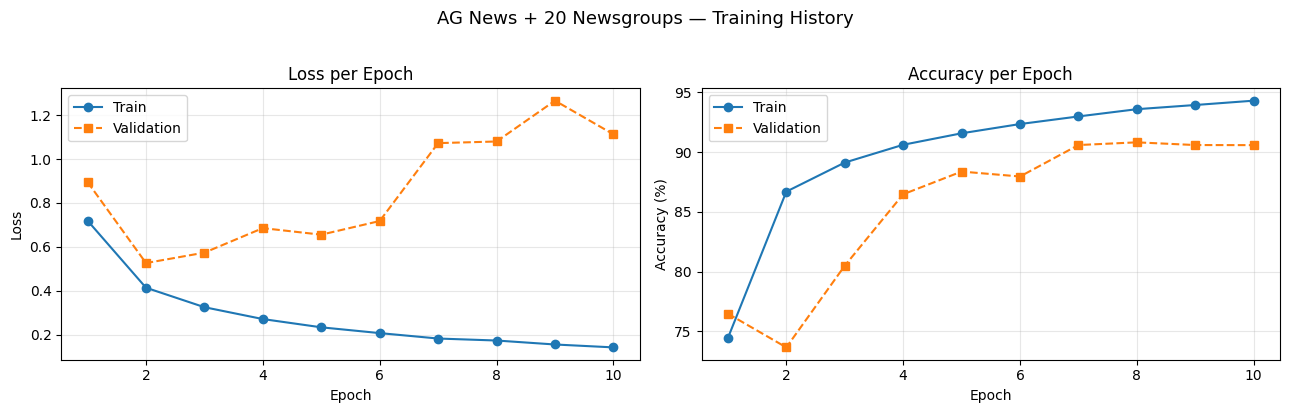

In [11]:
epochs = range(1, N_EPOCHS + 1)
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

axes[0].plot(epochs, history['train_loss'], 'o-', label='Train')
axes[0].plot(epochs, history['val_loss'],   's--', label='Validation')
axes[0].set_title('Loss per Epoch')
axes[0].set_xlabel('Epoch'); axes[0].set_ylabel('Loss')
axes[0].legend(); axes[0].grid(alpha=0.3)

axes[1].plot(epochs, [a * 100 for a in history['train_acc']], 'o-', label='Train')
axes[1].plot(epochs, [a * 100 for a in history['val_acc']],   's--', label='Validation')
axes[1].set_title('Accuracy per Epoch')
axes[1].set_xlabel('Epoch'); axes[1].set_ylabel('Accuracy (%)')
axes[1].legend(); axes[1].grid(alpha=0.3)

plt.suptitle('AG News + 20 Newsgroups — Training History', fontsize=13, y=1.02)
plt.tight_layout()
plt.savefig(f'{SAVE_DIR}/training_curves.png', dpi=150)
plt.show()

## 9. Evaluation — Best Checkpoint

In [12]:
model.load_state_dict(torch.load(f'{SAVE_DIR}/best_weights.pt', map_location=device, weights_only=True))
_, test_acc, preds, labels = evaluate(model, test_loader, criterion)

print(f'Test Accuracy: {test_acc:.2%}\n')
print(classification_report(labels, preds, target_names=LABEL_NAMES))

Test Accuracy: 90.82%

                precision    recall  f1-score   support

Tech & Science       0.92      0.92      0.92      4954
      Business       0.88      0.89      0.89      1900
    World News       0.89      0.90      0.89      2927
        Sports       0.96      0.94      0.95      2673
      Security       0.74      0.67      0.71       380

      accuracy                           0.91     12834
     macro avg       0.88      0.86      0.87     12834
  weighted avg       0.91      0.91      0.91     12834



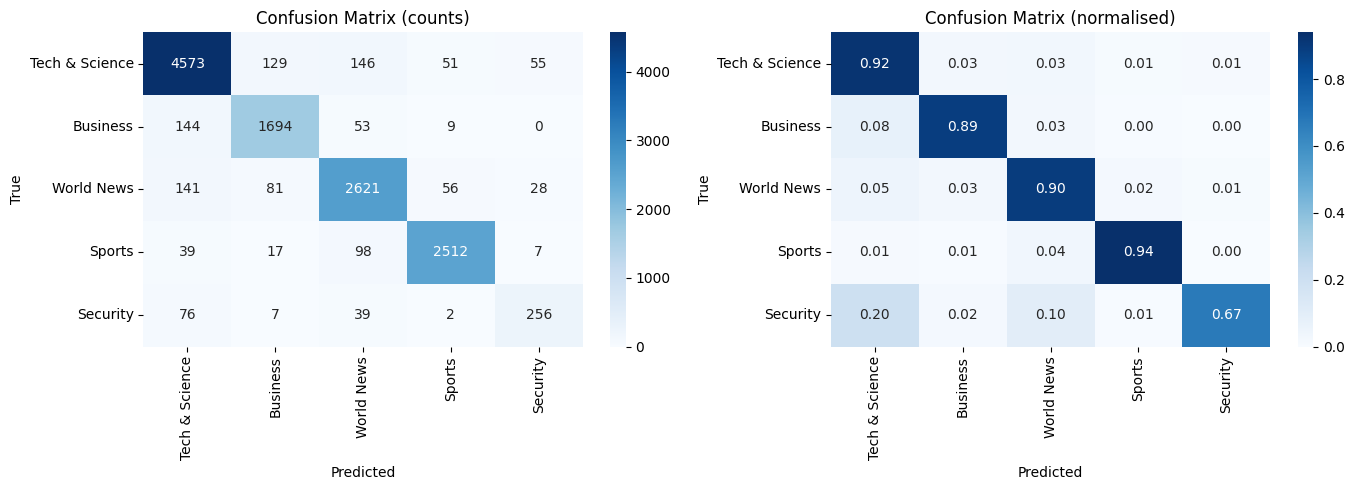

In [13]:
cm      = confusion_matrix(labels, preds)
cm_norm = cm.astype(float) / cm.sum(axis=1, keepdims=True)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for ax, data, fmt, title in zip(
    axes,
    [cm, cm_norm],
    ['d', '.2f'],
    ['Confusion Matrix (counts)', 'Confusion Matrix (normalised)']
):
    sns.heatmap(data, annot=True, fmt=fmt, cmap='Blues',
                xticklabels=LABEL_NAMES, yticklabels=LABEL_NAMES, ax=ax)
    ax.set_title(title)
    ax.set_xlabel('Predicted'); ax.set_ylabel('True')

plt.tight_layout()
plt.savefig(f'{SAVE_DIR}/confusion_matrix.png', dpi=150)
plt.show()

## 10. Save Full Model Artefacts

We save everything needed to run inference in the Next.js / FastAPI app:
- `best_weights.pt` — model weights  
- `vocab.pkl` — word2idx dictionary  
- `config.json` — all hyperparameters + label names

In [14]:
# 1. Vocabulary
with open(f'{SAVE_DIR}/vocab.pkl', 'wb') as f:
    pickle.dump(word2idx, f)
print(f'Saved vocab  -> {SAVE_DIR}/vocab.pkl  ({len(word2idx):,} tokens)')

# 2. Config (hyperparams + label names — everything needed to rebuild the model)
config = {
    'vocab_size' : VOCAB_SIZE,
    'embed_dim'  : EMBED_DIM,
    'hidden_dim' : HIDDEN_DIM,
    'n_layers'   : N_LAYERS,
    'n_classes'  : N_CLASSES,
    'dropout'    : DROPOUT,
    'max_seq_len': MAX_SEQ_LEN,
    'label_names': LABEL_NAMES,
}
with open(f'{SAVE_DIR}/config.json', 'w') as f:
    json.dump(config, f, indent=2)
print(f'Saved config -> {SAVE_DIR}/config.json')

# 3. Confirm weights file exists
weight_size = os.path.getsize(f'{SAVE_DIR}/best_weights.pt') / 1e6
print(f'Saved weights-> {SAVE_DIR}/best_weights.pt  ({weight_size:.1f} MB)')

print('\nAll artefacts saved:')
for f in os.listdir(SAVE_DIR):
    size = os.path.getsize(f'{SAVE_DIR}/{f}') / 1e3
    print(f'  {f:<30} {size:>8.1f} KB')

Saved vocab  -> saved_model/vocab.pkl  (40,002 tokens)
Saved config -> saved_model/config.json
Saved weights-> saved_model/best_weights.pt  (31.0 MB)

All artefacts saved:
  best_weights.pt                 31018.4 KB
  class_distribution.png             40.8 KB
  config.json                         0.3 KB
  confusion_matrix.png              100.5 KB
  training_curves.png                77.4 KB
  vocab.pkl                         508.3 KB


## 11. Reload Saved Model From Scratch & Test

This section simulates what the FastAPI server does — loads from disk with zero reliance on in-memory state.

In [15]:
# ── Load artefacts ─────────────────────────────────────────────────────────────
with open(f'{SAVE_DIR}/config.json') as f:
    cfg = json.load(f)

with open(f'{SAVE_DIR}/vocab.pkl', 'rb') as f:
    loaded_word2idx = pickle.load(f)

# ── Rebuild model architecture ────────────────────────────────────────────────
loaded_model = AttentionLSTM(
    vocab_size=cfg['vocab_size'],
    embed_dim=cfg['embed_dim'],
    hidden_dim=cfg['hidden_dim'],
    n_layers=cfg['n_layers'],
    n_classes=cfg['n_classes'],
    dropout=cfg['dropout']
).to(device)

loaded_model.load_state_dict(torch.load(f'{SAVE_DIR}/best_weights.pt', map_location=device, weights_only=True))
loaded_model.eval()

print('Model loaded successfully from disk.')
print(f'Classes: {cfg["label_names"]}')

Model loaded successfully from disk.
Classes: ['Tech & Science', 'Business', 'World News', 'Sports', 'Security']


In [16]:
# ── Inference helpers (using only loaded artefacts) ───────────────────────────

def encode_loaded(text: str):
    tokens = re.findall(r'\b[a-z0-9]+\b', text.lower())[:cfg['max_seq_len']]
    ids    = [loaded_word2idx.get(t, 1) for t in tokens]
    if len(ids) == 0:
        ids = [1]
    ids   += [0] * (cfg['max_seq_len'] - len(ids))
    return ids


@torch.no_grad()
def classify(text: str):
    x       = torch.tensor([encode_loaded(text)], dtype=torch.long).to(device)
    logits, weights = loaded_model(x)
    probs   = torch.softmax(logits, dim=-1).squeeze().cpu().numpy()
    pred_idx = int(probs.argmax())
    return {
        'label'      : cfg['label_names'][pred_idx],
        'confidence' : float(probs[pred_idx]),
        'all_probs'  : {cfg['label_names'][i]: float(p) for i, p in enumerate(probs)},
        'attn_weights': weights.squeeze().cpu().numpy(),
    }

print('Inference function ready.')

Inference function ready.


In [17]:
# ── Test on HN / Reddit-style headlines ───────────────────────────────────────
test_headlines = [
    # Tech & Science (AG Sci/Tech + 20NG comp/sci — same merged class)
    "Rust is now the second official language of the Linux kernel",
    "Apple announces M4 chip with 40% faster neural engine performance",
    "NASA confirms water ice deposits found near Mars south pole",
    "New CRISPR technique allows editing of multiple genes simultaneously",
    # Business
    "Federal Reserve holds interest rates steady amid inflation concerns",
    "OpenAI closes $6.6B funding round at $157B valuation",
    # World News
    "UN Security Council votes on ceasefire resolution in Gaza conflict",
    "G7 leaders agree on new sanctions framework targeting energy exports",
    # Sports
    "Manchester City wins Premier League title for the fourth consecutive season",
    "LeBron James becomes first NBA player to score 40000 career points",
    # Security (sci.crypt-era vocabulary: PGP, RSA, SSL — not modern ransomware headlines)
    "Question about exporting PGP public key block from MIT keyserver",
    "RSA key length debate: is 1024 bits still safe for SSL sessions",
]

print(f"{'Headline':<60}  {'Predicted':<12}  {'Confidence':>10}")
print('=' * 88)
for text in test_headlines:
    result = classify(text)
    print(f"{text[:58]:<60}  {result['label']:<12}  {result['confidence']:>9.1%}")

Headline                                                      Predicted     Confidence
Rust is now the second official language of the Linux kern    Tech & Science      98.7%
Apple announces M4 chip with 40% faster neural engine perf    Tech & Science      98.9%
NASA confirms water ice deposits found near Mars south pol    Tech & Science      99.9%
New CRISPR technique allows editing of multiple genes simu    Tech & Science      91.6%
Federal Reserve holds interest rates steady amid inflation    Business          95.1%
OpenAI closes $6.6B funding round at $157B valuation          Business          48.8%
UN Security Council votes on ceasefire resolution in Gaza     World News       100.0%
G7 leaders agree on new sanctions framework targeting ener    World News        72.6%
Manchester City wins Premier League title for the fourth c    Sports            97.1%
LeBron James becomes first NBA player to score 40000 caree    Sports            99.8%
Question about exporting PGP public key block

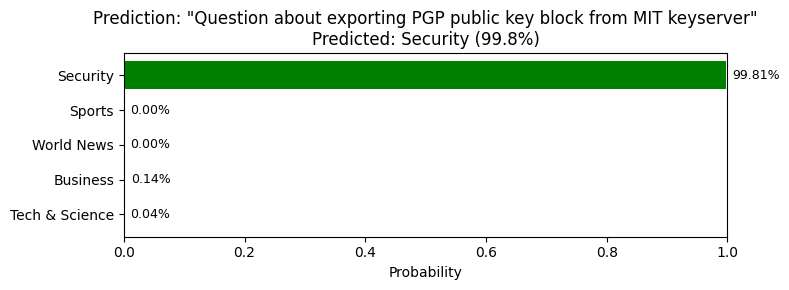

In [18]:
# ── Probability breakdown for one example ─────────────────────────────────────
sample = "Question about exporting PGP public key block from MIT keyserver"
result = classify(sample)

fig, ax = plt.subplots(figsize=(8, 3))
names  = list(result['all_probs'].keys())
values = list(result['all_probs'].values())
colors = ['green' if n == result['label'] else 'steelblue' for n in names]

ax.barh(names, values, color=colors)
ax.set_xlim(0, 1)
ax.set_xlabel('Probability')
ax.set_title(f'Prediction: "{sample}"\nPredicted: {result["label"]} ({result["confidence"]:.1%})')
for i, v in enumerate(values):
    ax.text(v + 0.01, i, f'{v:.2%}', va='center', fontsize=9)
plt.tight_layout()
plt.savefig(f'{SAVE_DIR}/sample_prediction.png', dpi=150)
plt.show()

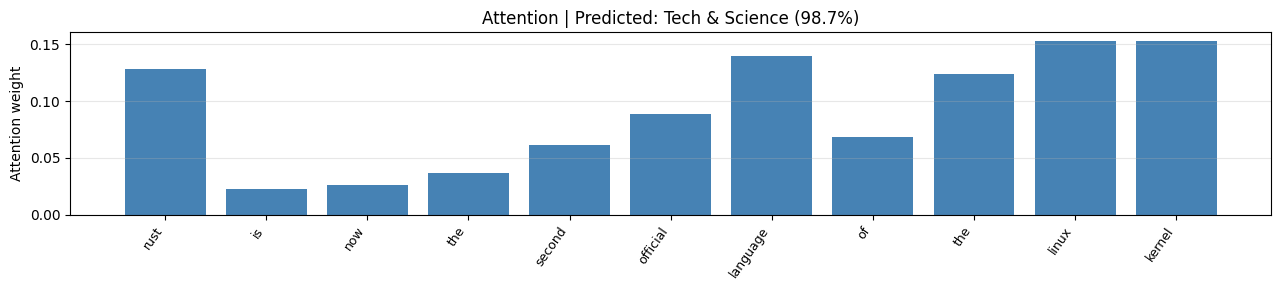

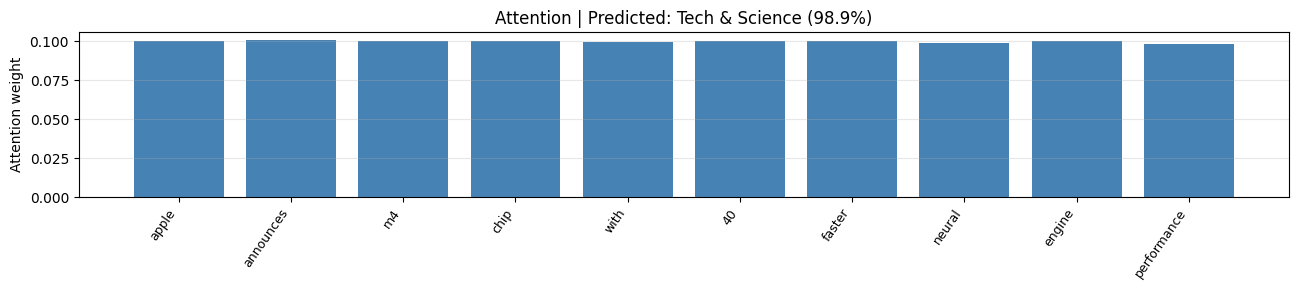

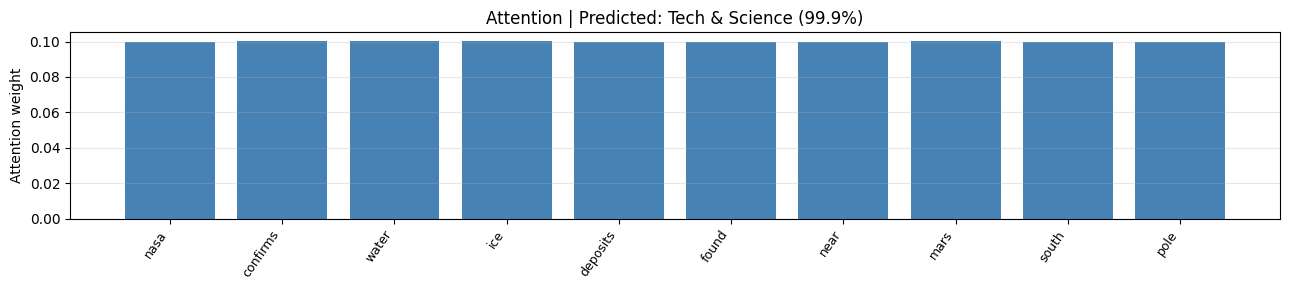

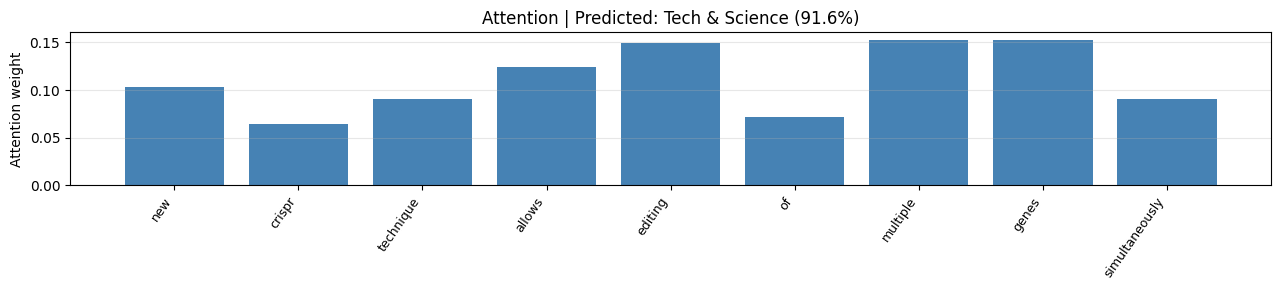

In [19]:
# ── Attention visualisation on loaded model ───────────────────────────────────
def plot_attention(text: str, max_tokens: int = 35):
    tokens  = re.findall(r'\b[a-z0-9]+\b', text.lower())[:max_tokens]
    result  = classify(text)
    weights = result['attn_weights'][:len(tokens)]

    fig, ax = plt.subplots(figsize=(13, 3))
    ax.bar(range(len(tokens)), weights, color='steelblue')
    ax.set_xticks(range(len(tokens)))
    ax.set_xticklabels(tokens, rotation=55, ha='right', fontsize=9)
    ax.set_ylabel('Attention weight')
    ax.set_title(f'Attention | Predicted: {result["label"]} ({result["confidence"]:.1%})')
    ax.grid(axis='y', alpha=0.3)
    plt.tight_layout()
    plt.show()

for headline in test_headlines[:4]:
    plot_attention(headline)

## 12. Saved Artefacts Summary

| File | Purpose |
|---|---|
| `saved_model/best_weights.pt` | Trained model weights — load with `torch.load` |
| `saved_model/vocab.pkl` | `word2idx` dict — needed to encode text at inference time |
| `saved_model/config.json` | Architecture params + label names — rebuild model without the notebook |

### Loading in FastAPI (3 lines)
```python
cfg   = json.load(open('saved_model/config.json'))
w2idx = pickle.load(open('saved_model/vocab.pkl', 'rb'))
model = AttentionLSTM(**{k: cfg[k] for k in ['vocab_size','embed_dim','hidden_dim','n_layers','n_classes','dropout']})
model.load_state_dict(torch.load('saved_model/best_weights.pt', weights_only=True))
```

### Categories
```
0 Tech & Science   1 Business   2 World News
3 Sports           4 Security
```